In [1]:
from src.data import (
    load_all_data, get_latest_documents, build_topic_lookups, add_topic_depth,
    reparent_topics, prune_empty_topics, prune_empty_topics_translated,
    drop_topic_subtrees, summarize_transactions, split_by_subject,
)
from src.features import build_feature_matrix, prepare_seq
from src.models import create_model_lstm
from src.post_analysis import (
    predict_per_skill_probs,
    build_skill_info,
    build_pairwise_deltas,
    topic_topic_interactions_by_outcome, add_reverse_directionality,
    prerequisite_score,
    build_curriculum_graph, plot_curriculum_graph,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Configuration
from src.config import MASK_VALUE

SUBJECTS = ['math', 'german']

# Topic-tree surgery (consistent with DKT_training.ipynb).
TOPICS_TO_REPARENT = [2026, 2027, 2028]
REPARENT_UNDER     = 1
TOPICS_TO_DROP     = [2029, 3425]

# Model architecture (must match training: 256 LSTM units, no dropout).
params = {
    'batch_size'     : 32,
    'mask_value'     : MASK_VALUE,
    'recurrent_units': 256,
    'dropout_rate'   : 0.0,
    'optimizer'      : 'adam',
    'verbose'        : 0,
}

# Delta scaling mode for the topic-pair analysis:
#   'absolute' → raw |Δ P(correct)|
#   'relative' → |Δ| / (1 - p_current) for correct answers,
#                |Δ| /     p_current   for wrong answers.
# Headroom-normalized: a small absolute change near p≈1 (when correct) or
# near p≈0 (when wrong) is amplified, since the model had little room to move.
DELTA_MODE = 'absolute'

# When True, scale each source topic's correct/wrong mean by the share of
# attempts it received in that outcome class:
#   r_correct = n_correct / (n_correct + n_wrong)
#   r_wrong   = n_wrong   / (n_correct + n_wrong)
# This stops a tiny but high-magnitude wrong-answer pool from dominating the
# directionality signal on a topic that is nearly always answered correctly.
BALANCE_BY_OUTCOME_RATIO = False

# Tree relations between topics A and B (transitive — walk full ancestor chain).
RELATION_COLORS = {
    'ancestor→descendant': 'tab:blue',
    'descendant→ancestor': 'tab:orange',
    'sibling':             'tab:green',
    'other':               'tab:gray',
}

# DKT Post-Training Analysis

We use the trained DKT models (math & german) to extract pairwise topic interactions on the entire dataset. For each pair of topics (A, B), we compute |Δ P(correct on B)| around an answer to A, **split by whether A was answered correctly or wrongly**.

Two macro metrics drive the analysis:

- **`strength`** = (Δ_correct + Δ_wrong) / 2 — overall intensity of the relation
- **`directionality`** ∈ [-1, +1] = (Δ_correct − Δ_wrong) / `strength`
  - +1 → answering A correctly drives B's probability ⇒ **B is a prerequisite of A**
  - −1 → answering A wrongly crashes B's probability  ⇒ **A is a prerequisite of B**
  - ~0 → both directions equal ⇒ complementary / co-occurring topics

A coherence check (directionality of A→B vs directionality of B→A) validates that real prerequisite relations are asymmetric.

## §1. Data Loading
Load raw tables and apply the same topic-tree surgery used during training.

In [3]:
dfs       = load_all_data()
documents = get_latest_documents(documents=dfs['documents'])

dfs['topic_trees'] = reparent_topics(
    dfs['topic_trees'], TOPICS_TO_REPARENT, new_parent_id=REPARENT_UNDER,
)
dfs['topic_trees']       = prune_empty_topics(dfs['topic_trees'], documents)
dfs['topics_translated'] = prune_empty_topics_translated(
    dfs['topics_translated'], dfs['topic_trees'], documents,
)
dfs['topic_trees'], dfs['topics_translated'] = drop_topic_subtrees(
    dfs['topic_trees'], dfs['topics_translated'], TOPICS_TO_DROP,
)

lookups = build_topic_lookups(dfs['topics_translated'], dfs['topic_trees'])
topics  = add_topic_depth(dfs['topics_translated'], lookups['child_to_parent'])

evaluated = summarize_transactions(dfs['transactions'], topics, documents)
math_df, german_df = split_by_subject(evaluated, topics)
subject_dfs = {'math': math_df, 'german': german_df}
print(f"math: {len(math_df):,} rows | german: {len(german_df):,} rows")

Depth distribution across all topics:
       n_topics
depth          
0             2
1            25
2           103
3           188
4            39
5            20
Total transactions: 2134759
Evaluated transactions: 1401007 (65.6%)
Evaluated with unknown topic_id: 348782 (24.9%)
Evaluated with no estimatedDifficulty: 34228 (2.4%)
math: 293,465 rows | german: 758,760 rows


## §2. Per-subject Pipeline

For each subject, this single cell:
1. Builds the feature matrix and the per-user sequence representation,
2. Loads the trained DKT model from `weights/{subject}_bestmodel.weights.h5`,
3. Predicts P(correct) for **every skill at every step, for every user**,
4. Computes pairwise probability deltas split by the source-answer outcome,
5. Aggregates to topic-topic interactions among the **top-15 most-attempted topics** (plus their tree siblings) and adds reverse-direction coherence.

In [ ]:
import json, pathlib

CACHE_DIR = pathlib.Path('cache')

# ── Cache invalidation ────────────────────────────────────────────────────────
# Set FORCE_RECOMPUTE = True and re-run this cell whenever any of these change:
#   • model weights  (weights/{subject}_bestmodel.weights.h5)
#   • DELTA_MODE or BALANCE_BY_OUTCOME_RATIO (config cell above)
#   • source data    (transactions, topic tree)
# Otherwise the cached parquet/JSON files are loaded directly, skipping the
# expensive DKT inference (~5–10 min per subject on CPU).
FORCE_RECOMPUTE = False

def _cache_paths(subject):
    return {
        'outcome':    CACHE_DIR / f'{subject}_outcome_with_reverse.parquet',
        'skill_info': CACHE_DIR / f'{subject}_skill_info.parquet',
        'focus_ids':  CACHE_DIR / f'{subject}_focus_topic_ids.json',
    }

def _all_cached(subject):
    return all(p.exists() for p in _cache_paths(subject).values())

# ─────────────────────────────────────────────────────────────────────────────

X, skill_info, focus_topic_ids = {}, {}, {}
outcome_with_reverse = {}

for subject in SUBJECTS:
    paths = _cache_paths(subject)

    if not FORCE_RECOMPUTE and _all_cached(subject):
        # ── Fast path: load pre-computed results ─────────────────────────
        outcome_with_reverse[subject] = pd.read_parquet(paths['outcome'])
        skill_info[subject]           = pd.read_parquet(paths['skill_info'])
        focus_topic_ids[subject]      = set(json.loads(paths['focus_ids'].read_text()))
        print(f"{subject}: loaded from cache  ({paths['outcome']})")
        continue

    # ── Slow path: full DKT inference + aggregation ───────────────────────
    # Runs the trained LSTM over every user sequence to get per-skill P(correct),
    # then aggregates to topic-pair deltas split by answer outcome.
    print(f"\n=== {subject.upper()} — computing (several minutes) ===")
    X[subject] = build_feature_matrix(subject_dfs[subject], documents)
    seq, fd, sd = prepare_seq(X[subject])   # mutates X[subject]: adds 'skill' column

    p   = {**params, 'best_model_weights': f'weights/{subject}_bestmodel.weights.h5'}
    dkt = create_model_lstm(fd, sd, p)
    dkt.load_weights(p['best_model_weights'])

    user_row_idx = X[subject].groupby('user_id').indices
    skill_probs  = predict_per_skill_probs(
        seq, dkt, user_row_idx, fd, p['batch_size'], progress=True,
    )

    skill_info[subject] = build_skill_info(X[subject], lookups['id_to_name'])
    top15_ids = (skill_info[subject]
                 .groupby('topic_id', as_index=False)['n_attempts'].sum()
                 .nlargest(15, 'n_attempts')['topic_id']
                 .tolist())
    focus_topic_ids[subject] = set(top15_ids)

    # Drop skills outside the top-15 topics — they are never used as delta targets,
    # so removing them now keeps the delta matrix small without affecting results.
    top15_skill_ids = set(
        skill_info[subject]
        .loc[skill_info[subject]['topic_id'].isin(focus_topic_ids[subject]), 'skill']
    )
    skill_probs = skill_probs[skill_probs['skill'].isin(top15_skill_ids)]

    (wide_pc, _, delta_all, src_skill, _, _, src_correct, before_all) = (
        build_pairwise_deltas(X[subject], skill_probs, user_row_idx)
    )

    oi = topic_topic_interactions_by_outcome(
        wide_pc, delta_all, src_skill, src_correct,
        skill_info[subject], focus_topic_ids[subject],
        lookups['child_to_parent'],
        before_all=before_all, mode=DELTA_MODE,
        balance_by_outcome_ratio=BALANCE_BY_OUTCOME_RATIO,
    )
    df = add_reverse_directionality(oi)

    # Normalise directionality to [-1, 1] by the per-subject maximum so that
    # comparisons across subjects are on the same scale.
    scale = df['directionality'].abs().max()
    if scale > 0:
        df[['directionality', 'reverse_directionality', 'asymmetry']] /= scale

    outcome_with_reverse[subject] = df
    print(f"  events: {delta_all.shape[0]:,} | "
          f"correct: {(src_correct == 2).sum():,} | "
          f"wrong: {(src_correct == 0).sum():,} | "
          f"top-15 → {len(oi)} pairs | "
          f"mode={DELTA_MODE} | balanced={BALANCE_BY_OUTCOME_RATIO}")

    # ── Save to cache ─────────────────────────────────────────────────────
    CACHE_DIR.mkdir(exist_ok=True)
    outcome_with_reverse[subject].to_parquet(paths['outcome'], index=False)
    skill_info[subject].to_parquet(paths['skill_info'], index=False)
    paths['focus_ids'].write_text(json.dumps(list(focus_topic_ids[subject])))
    print(f"  saved to {CACHE_DIR}/")

## §3. Math Analysis

In [5]:
# Top topic pairs by |directionality| — math.
math_top = (outcome_with_reverse['math']
            .assign(_abs=lambda d: d['directionality'].abs())
            .sort_values('_abs', ascending=False)
            .drop(columns='_abs')
            .head(20)
            .reset_index(drop=True))
math_top[['source_name', 'target_name', 'relation',
          'strength', 'directionality',
          'reverse_directionality', 'asymmetry',
          'n_obs_correct', 'n_obs_wrong']]

,source_name,target_name,relation,strength,directionality,reverse_directionality,asymmetry,n_obs_correct,n_obs_wrong
0,Number sets,Function term,other,0.086668,-1.000000,-0.192890,-0.807110,12722,758
1,Number sets,Roots,sibling,0.056969,-0.934468,0.126062,-1.060529,12722,758
2,Number sets,Linear equations,other,0.070419,-0.904998,0.003480,-0.908478,12722,758
3,Number sets,Powers,sibling,0.071680,-0.889354,-0.084817,-0.804536,12722,758
4,Number sets,Factorize,other,0.089013,-0.889058,0.056419,-0.945477,12722,758
5,Number sets,Vectors,other,0.090667,-0.881804,0.010416,-0.892220,12722,758
6,Number sets,Fraction terms,other,0.062470,-0.874420,-0.155276,-0.719144,12722,758
7,Number sets,Beam sets,other,0.059117,-0.862092,-0.076823,-0.785269,12722,758
8,Number sets,Quadratic functions,other,0.062476,-0.847114,-0.053089,-0.794024,12722,758
9,Number sets,Binomial formulas,other,0.060246,-0.820654,-0.002529,-0.818126,12722,758


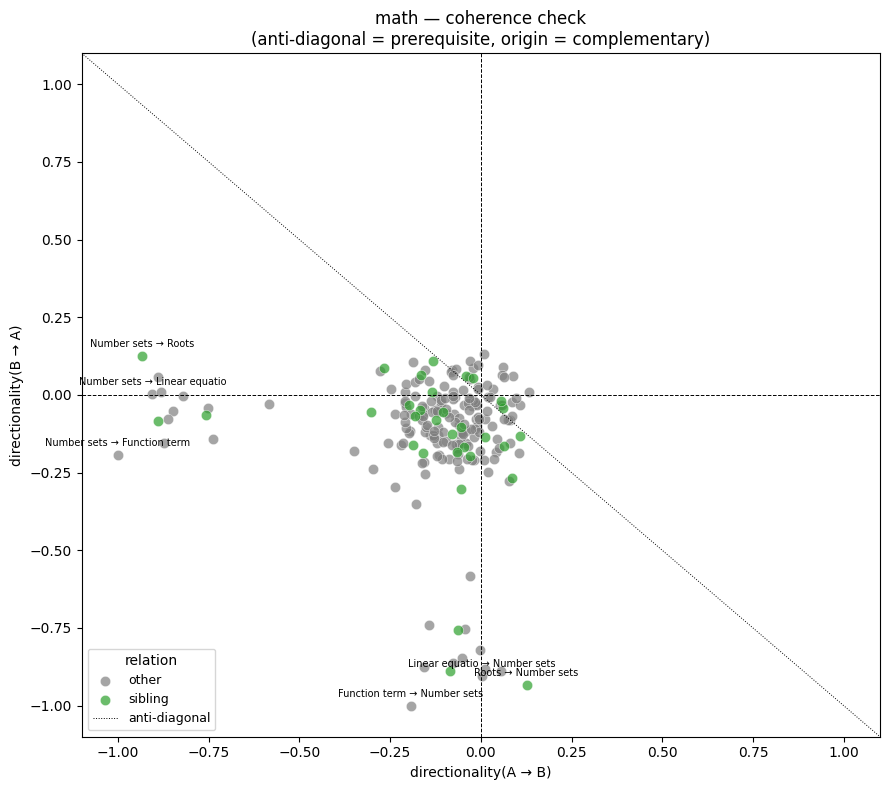

In [6]:
# Coherence scatter — math. Real prerequisite pairs sit near the anti-diagonal
# (top-left or bottom-right); complementary topics cluster at the origin.
df = outcome_with_reverse['math'].dropna(
    subset=['directionality', 'reverse_directionality']
)
fig, ax = plt.subplots(figsize=(9, 8))
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.7, s=55, edgecolors='white', linewidths=0.4)

lim = max(df['directionality'].abs().max(),
          df['reverse_directionality'].abs().max()) * 1.1
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(0, color='black', lw=0.7, ls='--')
ax.plot([-lim, lim], [lim, -lim], color='black', lw=0.7, ls=':', label='anti-diagonal')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

extremes = (df.assign(_r=lambda d: d['directionality']**2 +
                                    d['reverse_directionality']**2)
              .nlargest(6, '_r'))
for _, row in extremes.iterrows():
    ax.annotate(f"{row['source_name'][:14]} → {row['target_name'][:14]}",
                (row['directionality'], row['reverse_directionality']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_title('math — coherence check\n(anti-diagonal = prerequisite, origin = complementary)')
ax.legend(title='relation', fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

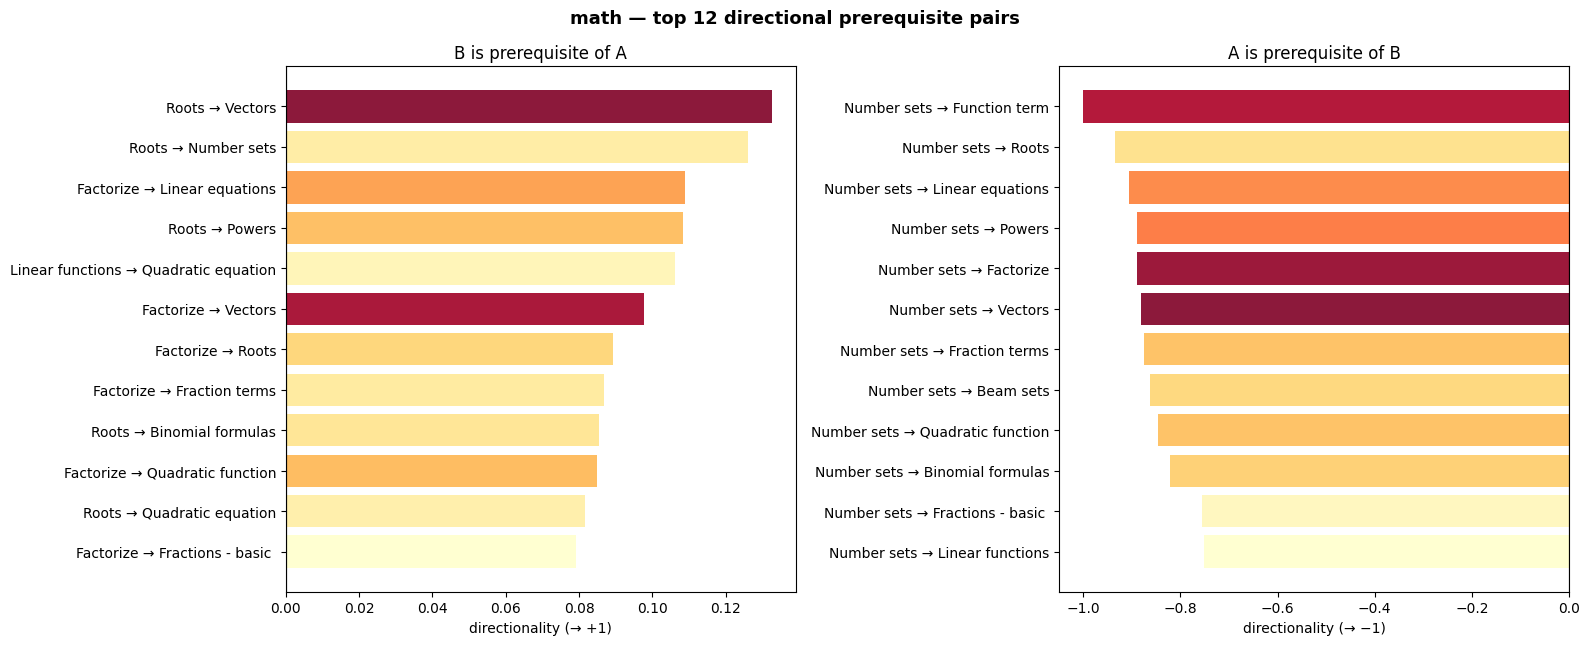

In [7]:
# Top prerequisite pairs — math. Bar color encodes relationship strength.
TOP_N = 12
df = outcome_with_reverse['math'].dropna(subset=['directionality', 'strength'])
high = df.nlargest(TOP_N,  'directionality').iloc[::-1]
low  = df.nsmallest(TOP_N, 'directionality').iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.42 * TOP_N + 1.5))
cmap = plt.cm.YlOrRd

def _bars(ax, data, title, xlabel):
    norm = plt.Normalize(data['strength'].min(), data['strength'].max())
    labels = [f"{r['source_name'][:18]} → {r['target_name'][:18]}"
              for _, r in data.iterrows()]
    ax.barh(labels, data['directionality'],
            color=cmap(norm(data['strength'])), alpha=0.9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(xlabel); ax.set_title(title)

_bars(ax1, high, 'B is prerequisite of A', 'directionality (→ +1)')
_bars(ax2, low,  'A is prerequisite of B', 'directionality (→ −1)')
plt.suptitle(f'math — top {TOP_N} directional prerequisite pairs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

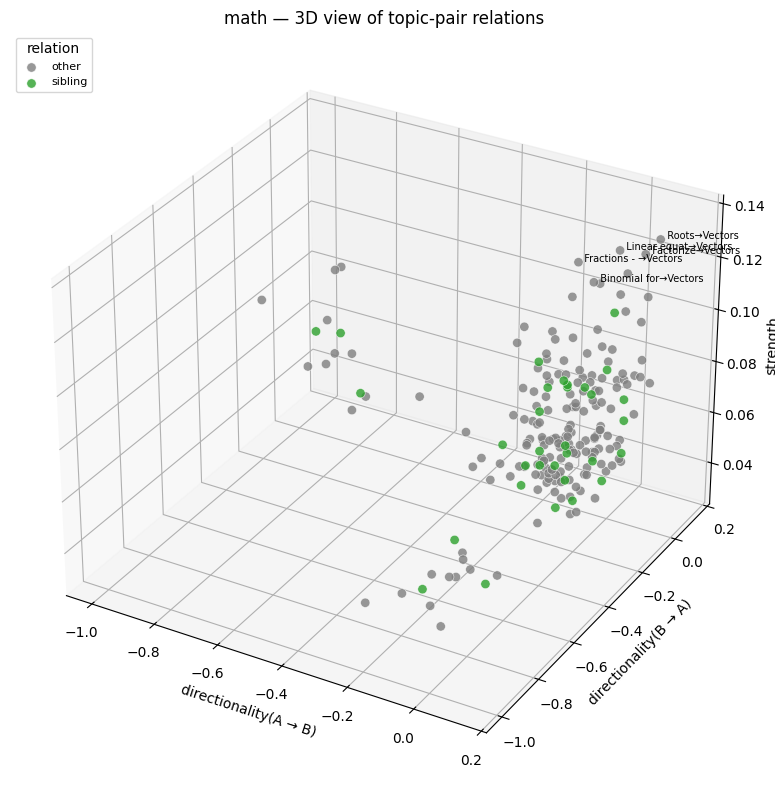

In [8]:
# 3D view — math: directionality(A→B), directionality(B→A), strength.
# Real prerequisite pairs lift along the diagonal of x and y opposite signs;
# complementary pairs sit near the (0, 0) line; strong pairs rise on z.
df = outcome_with_reverse['math'].dropna(
    subset=['directionality', 'reverse_directionality', 'strength']
)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'], grp['strength'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.8, s=45, edgecolors='white', linewidths=0.4)

# Annotate the 5 strongest pairs.
for _, row in df.nlargest(5, 'strength').iterrows():
    ax.text(row['directionality'], row['reverse_directionality'], row['strength'],
            f"  {row['source_name'][:12]}→{row['target_name'][:12]}",
            fontsize=7)

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_zlabel('strength')
ax.set_title('math — 3D view of topic-pair relations')
ax.legend(title='relation', fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

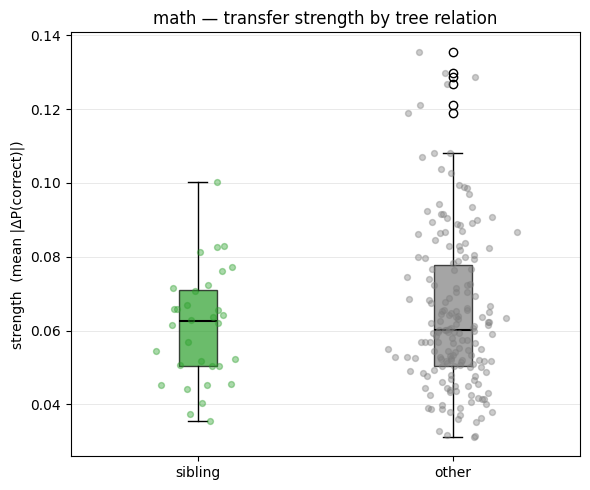

In [9]:
# Distribution of strength by relation type — math only.
fig, ax = plt.subplots(figsize=(6, 5))

df = outcome_with_reverse['math'].dropna(subset=['strength', 'relation'])
order = ['sibling', 'other']
colors = [RELATION_COLORS[r] for r in order]

data_by_rel = [df.loc[df['relation'] == r, 'strength'].values for r in order]
bp = ax.boxplot(data_by_rel, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)

for i, (rel, color) in enumerate(zip(order, colors), start=1):
    sub = df[df['relation'] == rel]['strength']
    ax.scatter(np.random.normal(i, 0.08, size=len(sub)), sub,
               color=color, alpha=0.4, s=18, zorder=3)

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, fontsize=10)
ax.set_ylabel('strength  (mean |ΔP(correct)|)')
ax.set_title('math — transfer strength by tree relation')
ax.grid(axis='y', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.show()


## §4. German Analysis

In [10]:
# Top topic pairs by |directionality| — german.
german_top = (outcome_with_reverse['german']
              .assign(_abs=lambda d: d['directionality'].abs())
              .sort_values('_abs', ascending=False)
              .drop(columns='_abs')
              .head(20)
              .reset_index(drop=True))
german_top[['source_name', 'target_name', 'relation',
            'strength', 'directionality',
            'reverse_directionality', 'asymmetry',
            'n_obs_correct', 'n_obs_wrong']]

,source_name,target_name,relation,strength,directionality,reverse_directionality,asymmetry,n_obs_correct,n_obs_wrong
0,Spelling difficult words,Particles,other,0.089492,-1.000000,-0.075049,-0.924951,22637,1327
1,Comma for enumerations,Particles,other,0.136350,-0.769670,-0.068363,-0.701307,15960,2590
2,Spelling difficult words,Determination of the elements of the sentence,other,0.060368,-0.758819,0.015159,-0.773979,22637,1327
3,Spelling difficult words,Separation and combination,sibling,0.071320,-0.701363,-0.195898,-0.505465,22637,1327
4,Comma for enumerations,Determination of the elements of the sentence,other,0.098762,-0.631539,0.158577,-0.790115,15960,2590
5,Comma for enumerations,Pronoun,other,0.134453,-0.611936,-0.149320,-0.462616,15960,2590
6,Spelling difficult words,Pronoun,other,0.086577,-0.596283,-0.109502,-0.486781,22637,1327
7,Spelling difficult words,Noun,other,0.072411,-0.583951,0.059392,-0.643342,22637,1327
8,Spelling difficult words,Upper and lower case,sibling,0.094097,-0.561206,-0.306778,-0.254428,22637,1327
9,Comma for enumerations,Separation and combination,other,0.097073,-0.542799,-0.309500,-0.233299,15960,2590


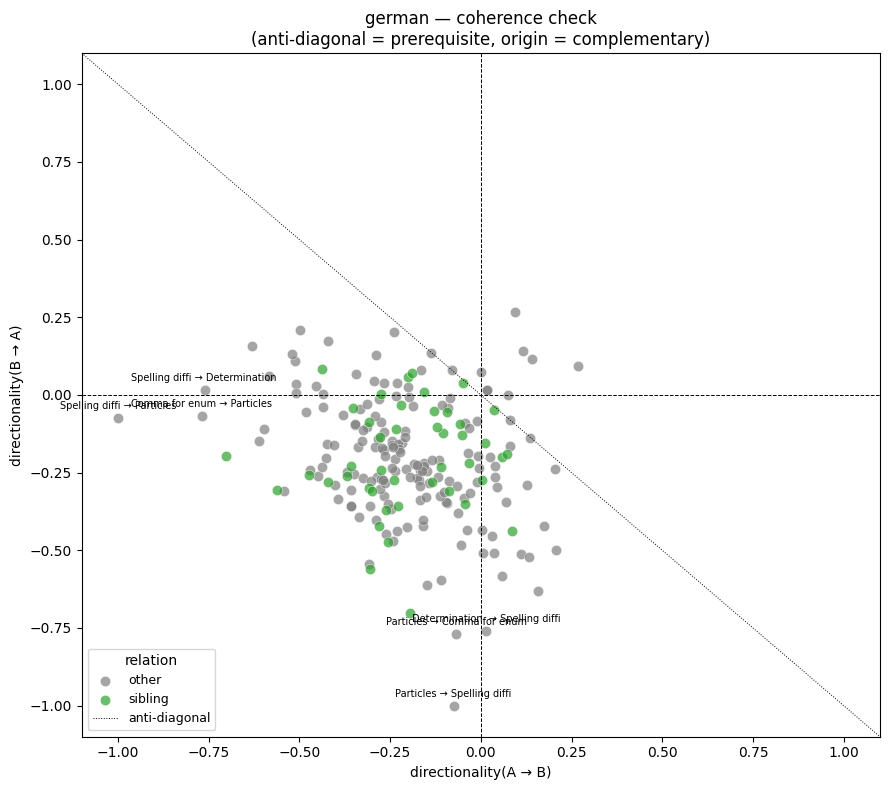

In [11]:
# Coherence scatter — german.
df = outcome_with_reverse['german'].dropna(
    subset=['directionality', 'reverse_directionality']
)
fig, ax = plt.subplots(figsize=(9, 8))
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.7, s=55, edgecolors='white', linewidths=0.4)

lim = max(df['directionality'].abs().max(),
          df['reverse_directionality'].abs().max()) * 1.1
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(0, color='black', lw=0.7, ls='--')
ax.plot([-lim, lim], [lim, -lim], color='black', lw=0.7, ls=':', label='anti-diagonal')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

extremes = (df.assign(_r=lambda d: d['directionality']**2 +
                                    d['reverse_directionality']**2)
              .nlargest(6, '_r'))
for _, row in extremes.iterrows():
    ax.annotate(f"{row['source_name'][:14]} → {row['target_name'][:14]}",
                (row['directionality'], row['reverse_directionality']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_title('german — coherence check\n(anti-diagonal = prerequisite, origin = complementary)')
ax.legend(title='relation', fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

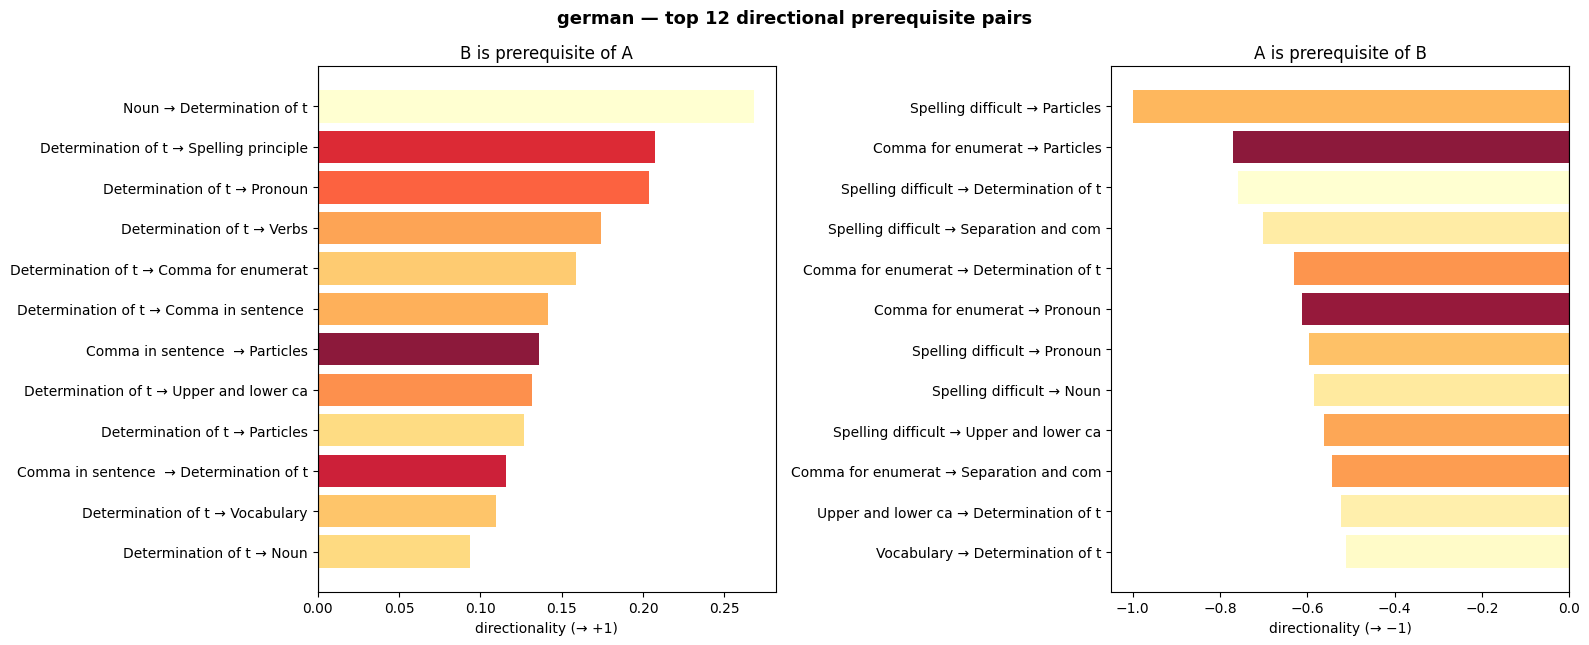

In [12]:
# Top prerequisite pairs — german. Bar color encodes relationship strength.
TOP_N = 12
df = outcome_with_reverse['german'].dropna(subset=['directionality', 'strength'])
high = df.nlargest(TOP_N,  'directionality').iloc[::-1]
low  = df.nsmallest(TOP_N, 'directionality').iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.42 * TOP_N + 1.5))
cmap = plt.cm.YlOrRd

def _bars(ax, data, title, xlabel):
    norm = plt.Normalize(data['strength'].min(), data['strength'].max())
    labels = [f"{r['source_name'][:18]} → {r['target_name'][:18]}"
              for _, r in data.iterrows()]
    ax.barh(labels, data['directionality'],
            color=cmap(norm(data['strength'])), alpha=0.9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(xlabel); ax.set_title(title)

_bars(ax1, high, 'B is prerequisite of A', 'directionality (→ +1)')
_bars(ax2, low,  'A is prerequisite of B', 'directionality (→ −1)')
plt.suptitle(f'german — top {TOP_N} directional prerequisite pairs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

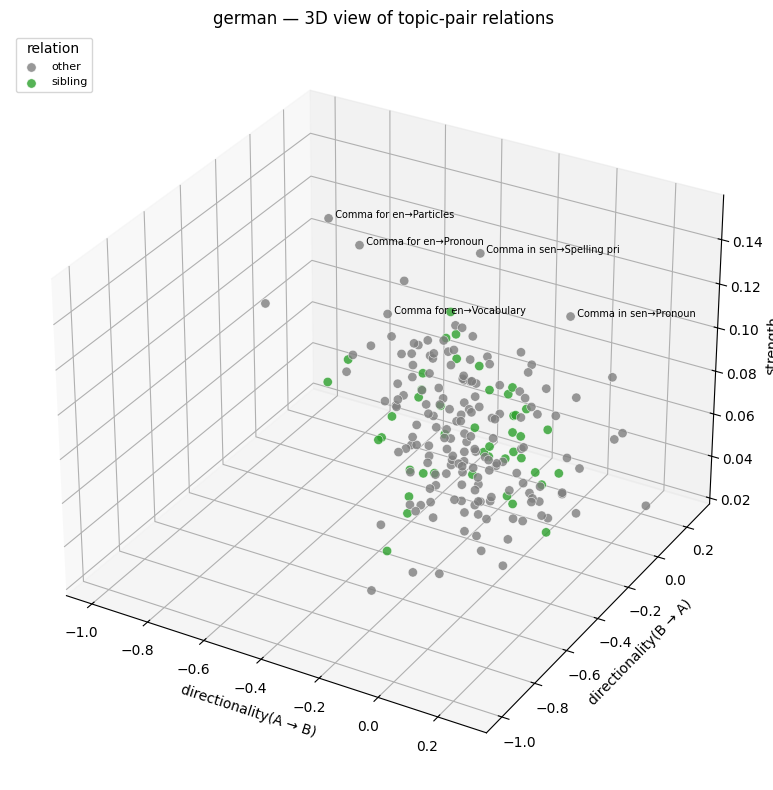

In [13]:
# 3D view — german: directionality(A→B), directionality(B→A), strength.
df = outcome_with_reverse['german'].dropna(
    subset=['directionality', 'reverse_directionality', 'strength']
)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'], grp['strength'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.8, s=45, edgecolors='white', linewidths=0.4)

for _, row in df.nlargest(5, 'strength').iterrows():
    ax.text(row['directionality'], row['reverse_directionality'], row['strength'],
            f"  {row['source_name'][:12]}→{row['target_name'][:12]}",
            fontsize=7)

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_zlabel('strength')
ax.set_title('german — 3D view of topic-pair relations')
ax.legend(title='relation', fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## §5. Cross-subject Comparison

,math,german
n_pairs,210.000,210.000
mean_strength,0.064,0.068
mean_|directionality|,0.146,0.230
%_strong_B_prereq_A,0.000,0.000
%_strong_A_prereq_B,7.619,27.143
%_complementary_(|d|<0.1),54.286,24.762


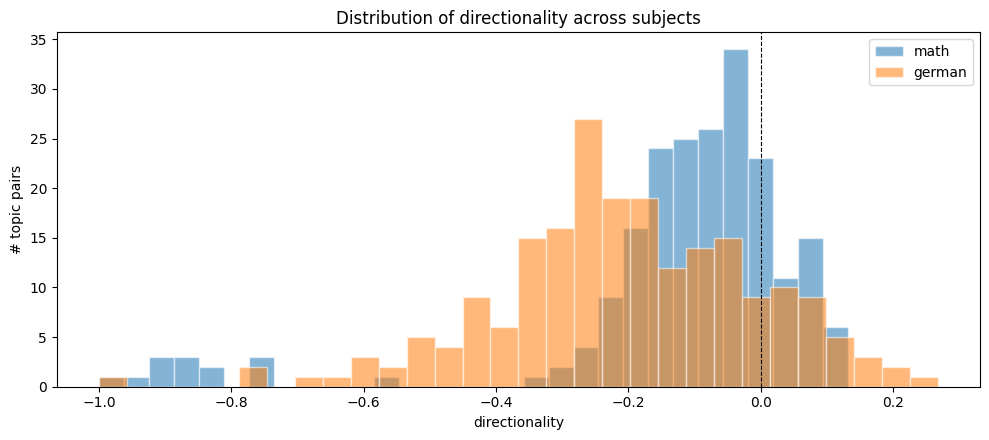

In [14]:
# Cross-subject summary: how directional are the topic-pair relations in each subject?
def _stats(df):
    df = df.dropna(subset=['directionality', 'strength'])
    return pd.Series({
        'n_pairs':                  len(df),
        'mean_strength':            df['strength'].mean(),
        'mean_|directionality|':    df['directionality'].abs().mean(),
        '%_strong_B_prereq_A':      (df['directionality'] >  0.3).mean() * 100,
        '%_strong_A_prereq_B':      (df['directionality'] < -0.3).mean() * 100,
        '%_complementary_(|d|<0.1)': (df['directionality'].abs() < 0.1).mean() * 100,
    })

summary = pd.DataFrame({s: _stats(outcome_with_reverse[s]) for s in SUBJECTS}).round(3)
display(summary)

# Side-by-side directionality distribution.
fig, ax = plt.subplots(figsize=(10, 4.5))
for subject, color in zip(SUBJECTS, ['tab:blue', 'tab:orange']):
    df = outcome_with_reverse[subject].dropna(subset=['directionality'])
    ax.hist(df['directionality'], bins=30, alpha=0.55, label=subject,
            color=color, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('directionality'); ax.set_ylabel('# topic pairs')
ax.set_title('Distribution of directionality across subjects')
ax.legend()
plt.tight_layout()
plt.show()

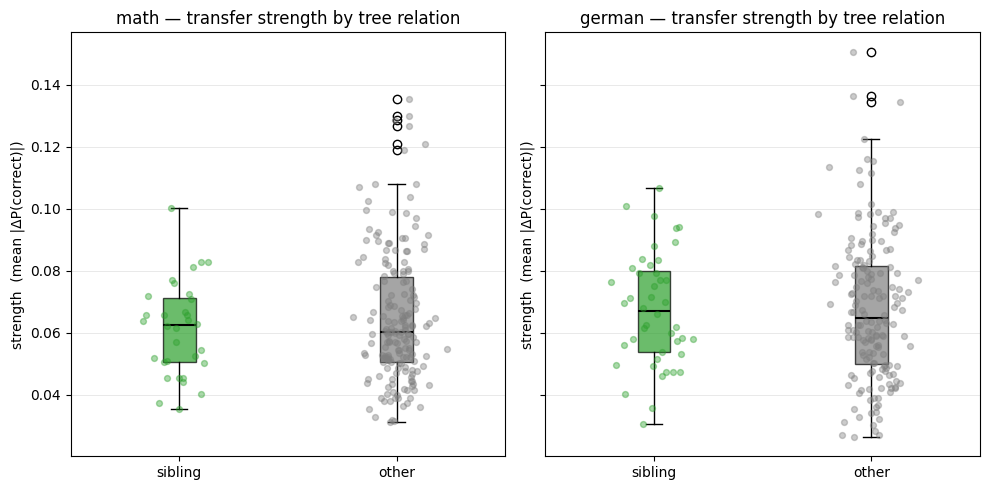

In [15]:
# Distribution of strength by relation type — both subjects side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, subject in zip(axes, SUBJECTS):
    df = outcome_with_reverse[subject].dropna(subset=['strength', 'relation'])
    order = ['sibling', 'other']
    colors = [RELATION_COLORS[r] for r in order]

    data_by_rel = [df.loc[df['relation'] == r, 'strength'].values for r in order]
    bp = ax.boxplot(data_by_rel, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=1.5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    for i, (rel, color) in enumerate(zip(order, colors), start=1):
        sub = df[df['relation'] == rel]['strength']
        ax.scatter(np.random.normal(i, 0.08, size=len(sub)), sub,
                   color=color, alpha=0.4, s=18, zorder=3)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(order, fontsize=10)
    ax.set_ylabel('strength  (mean |ΔP(correct)|)')
    ax.set_title(f'{subject} — transfer strength by tree relation')
    ax.grid(axis='y', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.show()

## Key Findings

- **The reverse-coherence check is a real falsifiability test.** A true prerequisite relation has to be asymmetric — answering A correctly should reveal B's mastery in a way that answering B correctly does not reveal A's. The `directionality(A→B)` vs `directionality(B→A)` scatter operationalizes this directly: pairs near the anti-diagonal pass the check; pairs near the origin behave symmetrically and are better described as **co-occurring / complementary** topics rather than prerequisites. This means the method comes with a built-in way to reject false positives, not just rank candidates.

- **The 3D view (directionality A→B, directionality B→A, strength) is where the analysis pays off.** Two-dimensional projections can hide that a strongly directional pair has near-zero `strength` — meaning the model barely moves either way. Reading the 3D scatter, the credible prerequisite candidates are pairs with simultaneously high `strength` and high |asymmetry|; everything at low z is decoration regardless of where it sits on the directionality plane.

- **Math and German give the method different shapes of evidence.** Math has many small, well-attempted leaf topics that share basic operations as ancestors — a structure where directional prerequisite signals are exactly what you'd expect to recover. German is flatter and more lexical: a much larger share of pairs falls in the symmetric / complementary region, which is consistent with a domain where many topics are parallel facets of language rather than ordered building blocks. Reading both subjects' coherence plots side by side is the clearest way to see this difference.

## §6. Prerequisite Score f(A, B)

An antisymmetric scalar that collapses both directed signals into one number per unordered pair:

$$f(A,B) \;=\; \frac{\text{directionality}(B \to A) \;-\; \text{directionality}(A \to B)}{2}$$

| Value | Meaning |
|-------|---------|
| **+1** | A is a strong prerequisite of B |
| **−1** | B is a strong prerequisite of A |
| **0** | complementary / symmetric |

By construction: $f(A,B) = -f(B,A)$ and $f(A,A) = 0$.


=== MATH — top 15 by |f(A,B)| ===


,source_name,target_name,relation,prerequisite_score,strength
0,Number sets,Roots,sibling,0.530265,0.056969
1,Roots,Number sets,sibling,-0.530265,0.065668
2,Number sets,Factorize,other,0.472739,0.089013
3,Factorize,Number sets,other,-0.472739,0.065291
4,Number sets,Linear equations,other,0.454239,0.070419
5,Linear equations,Number sets,other,-0.454239,0.061502
6,Vectors,Number sets,other,-0.446110,0.060142
7,Number sets,Vectors,other,0.446110,0.090667
8,Number sets,Binomial formulas,other,0.409063,0.060246
9,Binomial formulas,Number sets,other,-0.409063,0.062098



=== GERMAN — top 15 by |f(A,B)| ===


,source_name,target_name,relation,prerequisite_score,strength
0,Particles,Spelling difficult words,other,-0.462476,0.055727
1,Spelling difficult words,Particles,other,0.462476,0.089492
2,Comma for enumerations,Determination of the elements of the sentence,other,0.395058,0.098762
3,Determination of the elements of the sentence,Comma for enumerations,other,-0.395058,0.050053
4,Spelling difficult words,Determination of the elements of the sentence,other,0.386989,0.060368
5,Determination of the elements of the sentence,Spelling difficult words,other,-0.386989,0.049585
6,Determination of the elements of the sentence,Spelling principles,other,-0.353278,0.078628
7,Spelling principles,Determination of the elements of the sentence,other,0.353278,0.067172
8,Particles,Comma for enumerations,other,-0.350653,0.047514
9,Comma for enumerations,Particles,other,0.350653,0.136350



=== Antisymmetry check (max |f(A,B) + f(B,A)|, should be ~0) ===
  math: max error = 0.00e+00
  german: max error = 0.00e+00


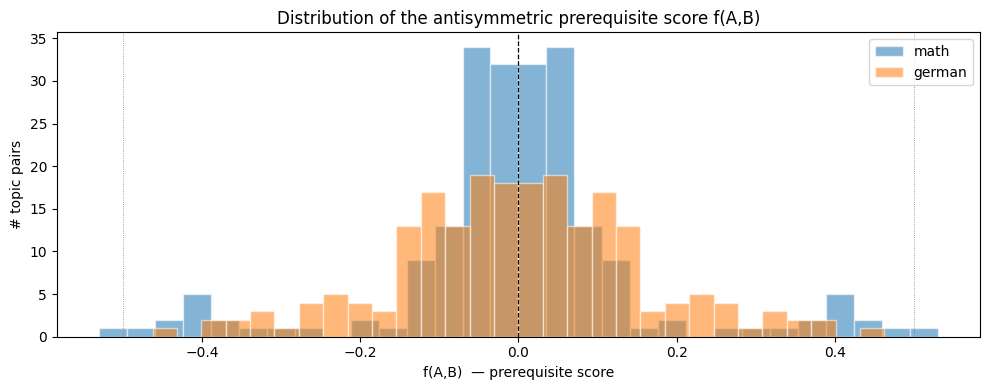

/var/folders/ds/bfzx964511l9xh7hkftcw1y40000gn/T/ipykernel_35655/3275763686.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


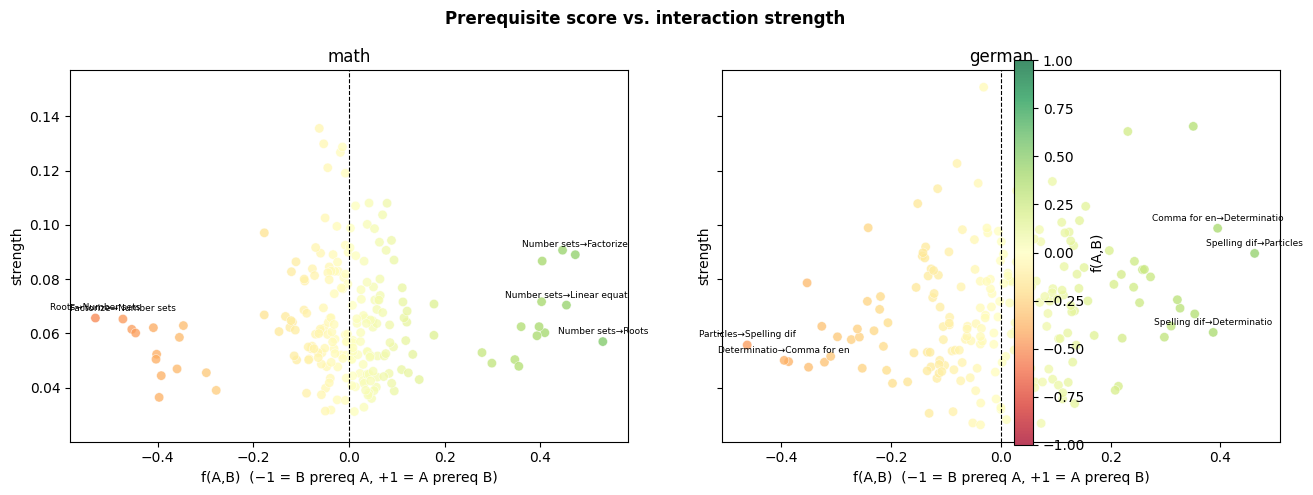

In [16]:
from src.post_analysis import prerequisite_score

prereq = {s: prerequisite_score(outcome_with_reverse[s]) for s in SUBJECTS}

# ── Top pairs by |f(A,B)| ──────────────────────────────────────────────────
TOP_N = 15
for subject in SUBJECTS:
    df = prereq[subject].dropna(subset=['prerequisite_score'])
    top = (df.assign(_abs=df['prerequisite_score'].abs())
             .sort_values('_abs', ascending=False)
             .drop(columns='_abs')
             .head(TOP_N)
             .reset_index(drop=True))
    print(f"\n=== {subject.upper()} — top {TOP_N} by |f(A,B)| ===")
    display(top[['source_name', 'target_name', 'relation',
                 'prerequisite_score', 'strength']])

# ── Antisymmetry sanity check ─────────────────────────────────────────────
# For every (A,B) row find (B,A) and verify f(A,B) ≈ −f(B,A).
print("\n=== Antisymmetry check (max |f(A,B) + f(B,A)|, should be ~0) ===")
for subject in SUBJECTS:
    df = prereq[subject][['source_topic', 'target_topic', 'prerequisite_score']].dropna()
    reverse = df.rename(columns={'source_topic': 'target_topic',
                                 'target_topic': 'source_topic',
                                 'prerequisite_score': 'f_reverse'})
    merged = df.merge(reverse, on=['source_topic', 'target_topic'])
    err = (merged['prerequisite_score'] + merged['f_reverse']).abs().max()
    print(f"  {subject}: max error = {err:.2e}")

# ── Distribution of f(A,B) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for subject, color in zip(SUBJECTS, ['tab:blue', 'tab:orange']):
    df = prereq[subject].dropna(subset=['prerequisite_score'])
    ax.hist(df['prerequisite_score'], bins=30, alpha=0.55, label=subject,
            color=color, edgecolor='white')
ax.axvline(0, color='black', lw=0.9, ls='--')
ax.axvline( 0.5, color='gray', lw=0.6, ls=':')
ax.axvline(-0.5, color='gray', lw=0.6, ls=':')
ax.set_xlabel('f(A,B)  — prerequisite score')
ax.set_ylabel('# topic pairs')
ax.set_title('Distribution of the antisymmetric prerequisite score f(A,B)')
ax.legend()
plt.tight_layout()
plt.show()

# ── Scatter: f(A,B) vs strength (size = |f|, colour = direction) ──────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, subject in zip(axes, SUBJECTS):
    df = prereq[subject].dropna(subset=['prerequisite_score', 'strength'])
    sc = ax.scatter(df['prerequisite_score'], df['strength'],
                    c=df['prerequisite_score'], cmap='RdYlGn',
                    vmin=-1, vmax=1, alpha=0.75, s=45,
                    edgecolors='white', linewidths=0.4)
    # Annotate the 5 most extreme pairs.
    for _, row in df.assign(_abs=df['prerequisite_score'].abs()).nlargest(5, '_abs').iterrows():
        ax.annotate(f"{row['source_name'][:12]}→{row['target_name'][:12]}",
                    (row['prerequisite_score'], row['strength']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points')
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('f(A,B)  (−1 = B prereq A, +1 = A prereq B)')
    ax.set_ylabel('strength')
    ax.set_title(f'{subject}')
plt.colorbar(sc, ax=axes, label='f(A,B)')
plt.suptitle('Prerequisite score vs. interaction strength', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## §7. Curriculum Graphs

A directed acyclic graph (DAG) per subject where an edge A → B means **"A is a prerequisite of B"**.

1. Keep only edges where `f(A,B) > 0` — direction is given, A is prerequisite of B
2. **Strength floor**: drop edges below the `STRENGTH_PERCENTILE` of strength — reliability gate
3. **f quality cutoff**: keep the top `(100 − F_PERCENTILE)%` by `f` among survivors
4. Sort by `f` descending; add each edge greedily, **skipping any edge that would create a cycle**
5. Exhaust the filtered list — isolated topics are valid output (no strong signal found)

Thresholds are computed **per subject** so math and german are calibrated independently.


=== MATH ===
  Nodes: 15  |  Edges: 27  |  Isolated: 0


,source_name,target_name,prerequisite_score,strength,relation
0,Number sets,Factorize,0.473,0.0890,other
1,Number sets,Linear equations,0.454,0.0704,other
2,Number sets,Vectors,0.446,0.0907,other
3,Number sets,Binomial formulas,0.409,0.0602,other
4,Number sets,Function term,0.404,0.0867,other
5,Number sets,Powers,0.402,0.0717,sibling
6,Number sets,Quadratic functions,0.397,0.0625,other
7,Number sets,Beam sets,0.393,0.0591,other
8,Number sets,Fraction terms,0.360,0.0625,other
9,Fraction terms,Factorize,0.177,0.0708,sibling



=== GERMAN ===
  Nodes: 14  |  Edges: 27  |  Isolated: 0


,source_name,target_name,prerequisite_score,strength,relation
0,Spelling difficult words,Particles,0.462,0.0895,other
1,Comma for enumerations,Determination of the elements of the sentence,0.395,0.0988,other
2,Comma for enumerations,Particles,0.351,0.1364,other
3,Spelling difficult words,Noun,0.322,0.0724,other
4,Vocabulary,Particles,0.273,0.0808,other
5,Verbs,Particles,0.262,0.0836,sibling
6,Upper and lower case,Particles,0.258,0.0835,other
7,Spelling difficult words,Pronoun,0.243,0.0866,other
8,Spelling difficult words,Comma in sentence structure,0.242,0.0770,other
9,Comma for enumerations,Pronoun,0.231,0.1345,other


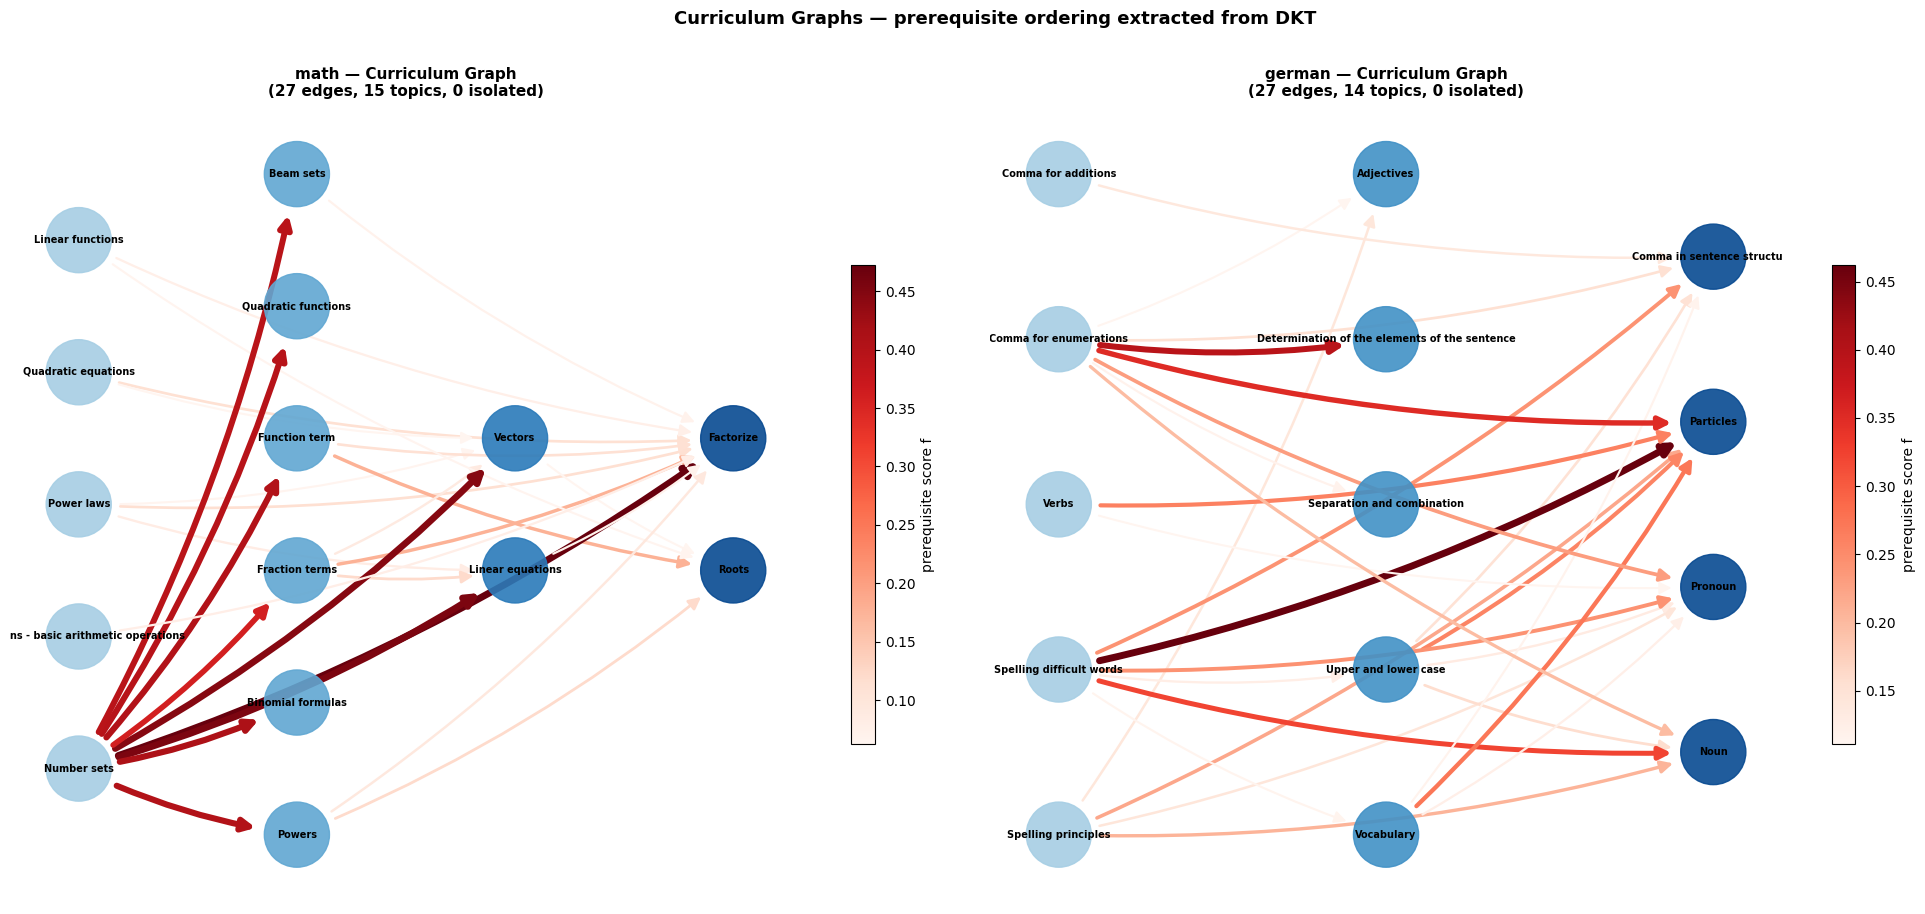


=== Topological study order ===

  math: Quadratic equations → Power laws → Linear functions → Number sets → Fractions - basic arithmetic operations → Binomial formulas → Function term → Powers → Quadratic functions → Beam sets → Fraction terms → Linear equations → Vectors → Factorize → Roots

  german: Spelling principles → Spelling difficult words → Verbs → Comma for enumerations → Comma for additions → Upper and lower case → Vocabulary → Determination of the elements of the sentence → Separation and combination → Adjectives → Noun → Particles → Pronoun → Comma in sentence structure


In [19]:
# ── Thresholds (per-subject percentiles) ────────────────────────────────────
STRENGTH_PERCENTILE = 50   # reliability floor: keep edges above this strength percentile
F_PERCENTILE        = 50   # quality cutoff:    keep top 50% by f among survivors

# ── Build one curriculum graph per subject ───────────────────────────────────
curriculum_edges, curriculum_graphs = {}, {}

for subject in SUBJECTS:
    edges_df, G = build_curriculum_graph(
        prereq[subject],
        strength_percentile=STRENGTH_PERCENTILE,
        f_percentile=F_PERCENTILE,
    )
    curriculum_edges[subject]  = edges_df
    curriculum_graphs[subject] = G

    import networkx as nx
    isolated   = list(nx.isolates(G))
    n_iso_names = [G.nodes[n].get('name', str(n)) for n in isolated]
    print(f"\n=== {subject.upper()} ===")
    print(f"  Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}  "
          f"|  Isolated: {len(isolated)}")
    if n_iso_names:
        print(f"  Isolated topics: {', '.join(n_iso_names)}")
    display(edges_df[['source_name', 'target_name',
                       'prerequisite_score', 'strength', 'relation']]
            .style.format({'prerequisite_score': '{:.3f}', 'strength': '{:.4f}'}))

# ── Visualise both graphs side by side ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, subject in zip(axes, SUBJECTS):
    plot_curriculum_graph(curriculum_graphs[subject], subject=subject, ax=ax)
plt.suptitle('Curriculum Graphs — prerequisite ordering extracted from DKT',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Topological ordering (one valid study sequence per subject) ──────────────
print("\n=== Topological study order ===")
for subject in SUBJECTS:
    G = curriculum_graphs[subject]
    try:
        order = list(nx.topological_sort(G))
        names = [G.nodes[n].get('name', str(n)) for n in order]
        print(f"\n  {subject}: {' → '.join(names)}")
    except nx.NetworkXUnfeasible:
        print(f"\n  {subject}: cycle detected — graph is not a DAG (bug)")